Бромберг Елизавета Андреевна, ИУ5-64Б

# Корреляционный анализ и визуализация данных

# Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set(style="ticks")

# 1) Загрузка данных

Загрузим датасет Wine из `scikit-learn` и преобразуем его в `pandas.DataFrame` для удобства анализа.

In [2]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
data = wine.frame.copy()
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# 2) Основные характеристики датасета

In [3]:
data.shape

(178, 14)

In [4]:
data.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

In [5]:
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


# 3) Проверка наличия пропусков в данных

In [6]:
data.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Пропусков в данных нет.

# 4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:
1. Понять, какие признаки наиболее сильно коррелируют с целевым признаком (`target`). Эти признаки потенциально будут наиболее информативными для моделей машинного обучения.
2. Найти признаки, которые сильно коррелируют между собой. Такие признаки могут быть избыточными, и иногда достаточно оставить один из них (особенно для линейных моделей).

In [7]:
data.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


In [8]:
# Корреляция признаков с целевым признаком (по убыванию модуля корреляции)
target_corr = data.corr(numeric_only=True)['target'].drop('target', errors='ignore')
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
target_corr

flavanoids                     -0.847498
od280/od315_of_diluted_wines   -0.788230
total_phenols                  -0.719163
proline                        -0.633717
hue                            -0.617369
alcalinity_of_ash               0.517859
proanthocyanins                -0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                        -0.328222
color_intensity                 0.265668
magnesium                      -0.209179
ash                            -0.049643
Name: target, dtype: float64

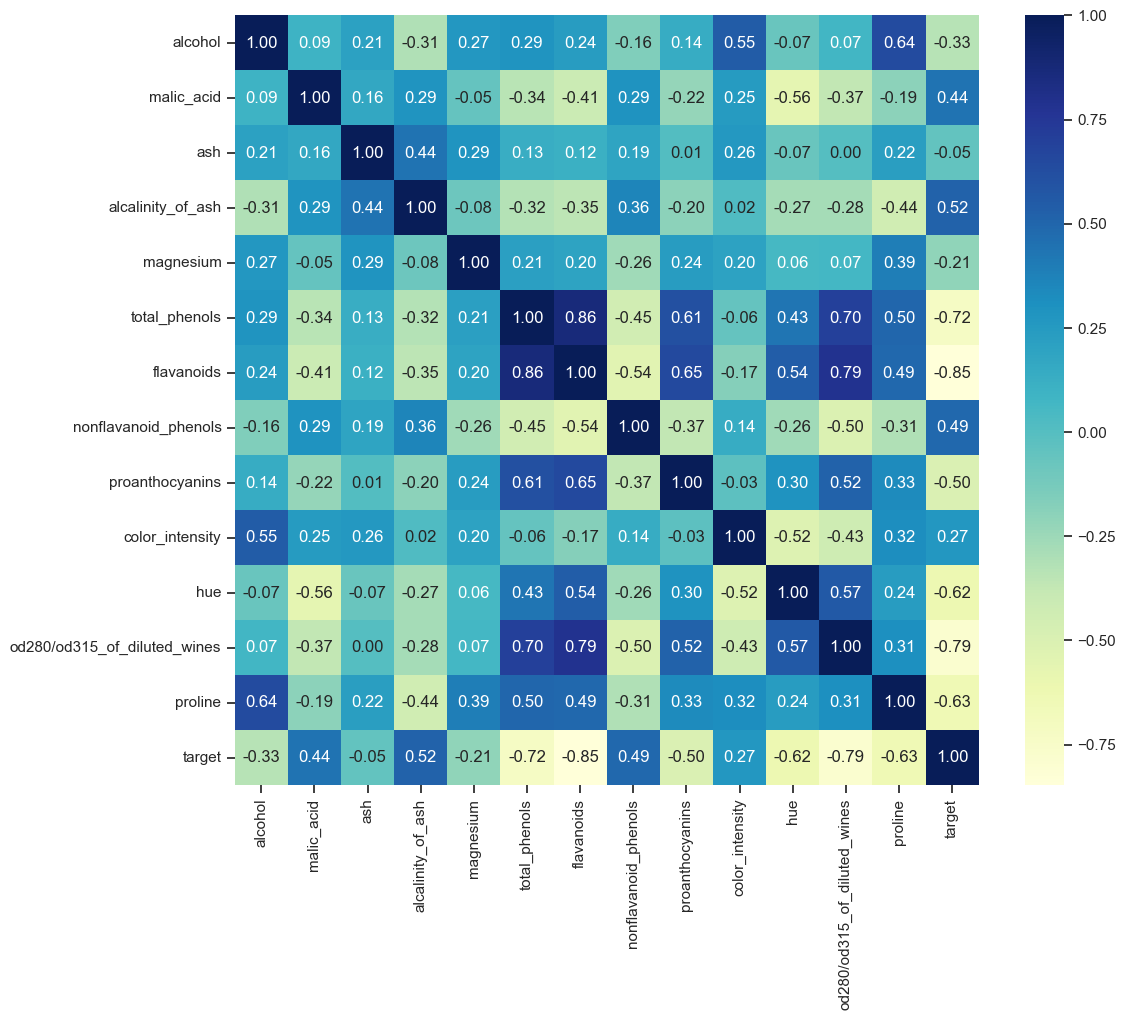

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), cmap='YlGnBu', annot=True, fmt='.2f')
plt.show()

# 5) Дополнительное требование: скрипичная диаграмма

Построим violin plot для произвольного признака относительно целевого признака.
В качестве примера возьмем признак `alcohol`.

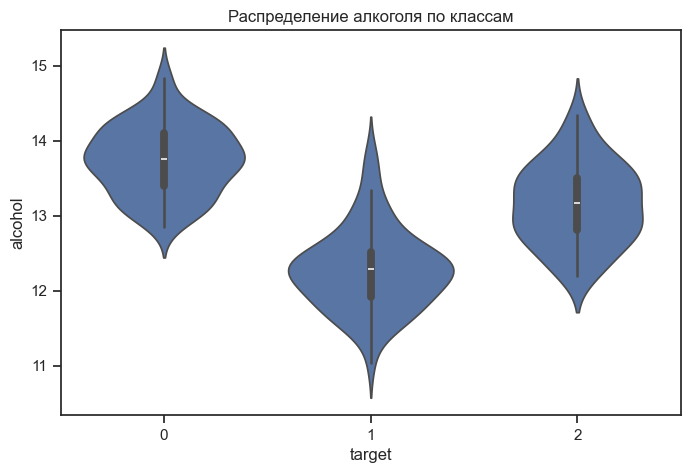

In [10]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='target', y='alcohol', data=data)
plt.title('Распределение алкоголя по классам')
plt.show()

# Выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель

1. В датасете целевым признаком `target` выступает класс вина (дискретная величина), а все остальные признаки являются непрерывными числовыми. В датасете нет пропусков. Данные готовы для построения моделей классификации машинного обучения без сложной дополнительной предобработки.

2. Целевой признак сильнее всего коррелирует с такими характеристиками, как `flavanoids` (-0.85), `od280/od315_of_diluted_wines` (-0.79), `total_phenols` (-0.72) и `proline` (-0.63). Эти признаки целесообразно использовать при построении моделей*.

3. Признаки `ash` (-0.05) и `magnesium` (-0.21) имеют наименьшую связь с целевой переменной. Их можно попробовать исключить из модели для уменьшения шума.

4. Наблюдается сильная взаимная корреляция между признаками `flavanoids`-`total_phenols` (0.86), `flavanoids`-`od280/od315_of_diluted_wines` (0.79) и `total_phenols`-`od280/od315_of_diluted_wines` (0.70), т.е. они несут схожую информацию. *Для линейных моделей (логистическая регрессия) рекомендуется оставить один из сильно коррелирующих признаков, например `flavanoids`, чтобы избежать мультиколлинеарности.